# Modeling peroxisomal dysfunction in multiple sclerosis - differential expression analysis
## Overview
This analysis aims to investigate the involvement of peroxisomal dysfunction in multiple sclerosis (MS) by integrating transcriptomic data with network-based approaches. Specifically, this notebook concentrates on identifying and analyzing differentially expressed genes associated with MS.

Author: Qing Zhang

Date of creation: 04/09/2025
Date of revision: 04/14/2025  

## Data sources
[GSE141797](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE141797)


In [1]:
library(DESeq2)
library(edgeR)
library(ggplot2)
library(png)
library(grid)
library(gridExtra)
library(tibble)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomicRanges

Loading required package: GenomeInfoDb



## Read raw reads and annotation

In [2]:
# read annotation information
anno <- read.csv("../data/GSE141797/SraRunTable.csv",header=T, stringsAsFactors=F)
anno <- anno[,c("Run","Sample.Name","Bases")]
# read condition information
cond <- read.table("../data/GSE141797/conditions.tsv",header=T, stringsAsFactors=F,sep="\t")

In [3]:
# combine the sample information (SRR) with the condition 
sam2cond <- merge(anno, cond, by.x=c("Sample.Name"), by.y = c("sample"))
sam2cond$condition <- factor(sam2cond$condition)

In [4]:
sam2cond

Sample.Name,Run,Bases,condition
<chr>,<chr>,<dbl>,<fct>
GSM4213364,SRR10662892,1987713750,patient
GSM4213365,SRR10662893,2015964150,patient
GSM4213366,SRR10662894,1901075700,patient
GSM4213367,SRR10662895,2115207375,patient
GSM4213368,SRR10662896,2201315850,patient
GSM4213369,SRR10662897,1890190350,patient
GSM4213370,SRR10662898,1963854600,patient
GSM4213371,SRR10662899,1714563450,patient
GSM4213372,SRR10662900,1850975700,patient


In [5]:
# read the raw reads count from STAR_SALMON
raw_counts <- read.table("../output/GSE141797/star_salmon/salmon.merged.gene_counts.tsv",header=T, row.names=1, stringsAsFactors=F)

In [6]:
raw_counts <- raw_counts[,-1]
head(raw_counts)

,SRR10662892,SRR10662893,SRR10662894,SRR10662895,SRR10662896,SRR10662897,SRR10662898,SRR10662899,SRR10662900,SRR10662901,SRR10662902,SRR10662903,SRR10662904,SRR10662905,SRR10662906,SRR10662907,SRR10662908,SRR10662909
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A1BG,4,7.764,10,7.000,9.405,13.000,10.000,8,0,0,2,9.00,2.000,6,0.000,24.000,4,13.000
A1BG-AS1,1,2.236,1,1.271,6.468,5.353,5.094,0,0,0,0,0.00,0.000,0,0.000,6.032,1,5.992
A1CF,37,22.000,24,45.000,85.000,2.000,39.000,4,5,18,31,35.00,48.000,14,10.000,11.000,23,20.000
A2M,15,12.999,7,7.000,16.590,32.770,12.000,4,0,8,6,9.98,12.335,8,4.996,9.847,3,13.000
A2M-AS1,13,4.000,3,5.000,11.000,30.000,21.000,0,0,13,5,10.00,8.665,8,4.000,8.000,3,0.000
A2ML1,13,4.000,0,16.000,6.000,2.000,10.000,0,0,5,11,2.00,10.000,9,0.000,0.000,13,1.000


In [7]:
reads_dis <- data.frame(cbind(colSums(raw_counts),sam2cond[,"Bases"]))
colnames(reads_dis) <- c("salmon","ori")
reads_dis

,salmon,ori
,<dbl>,<dbl>
SRR10662892,1302661,1987713750
SRR10662893,1078745,2015964150
SRR10662894,2008326,1901075700
SRR10662895,1270111,2115207375
SRR10662896,1679153,2201315850
SRR10662897,3006647,1890190350
SRR10662898,2117922,1963854600
SRR10662899,638384,1714563450
SRR10662900,416762,1850975700


#### Summary: 
It appears that the ratio of read counts from Salmon to the total number of bases varies significantly, which may indicate the presence of low-quality sequences.

## QC before do differential analysis

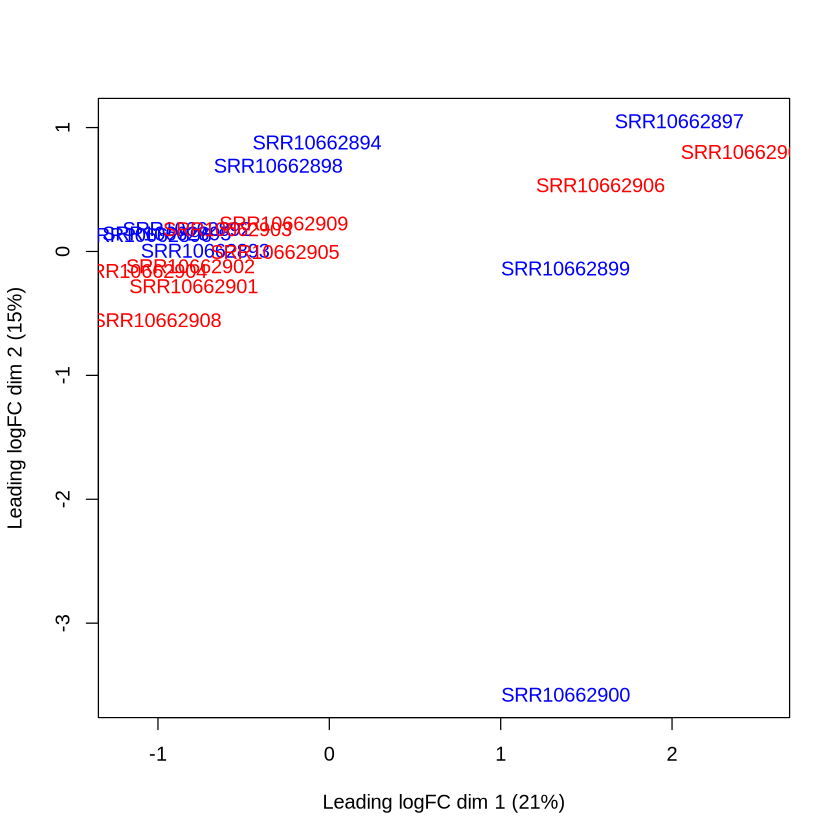

In [8]:
# generate the PCA to get the sense of the data
y <- DGEList(counts = raw_counts)
y <- calcNormFactors(y)
plotMDS(y,col=c(rep("blue",9),rep("red",9)))

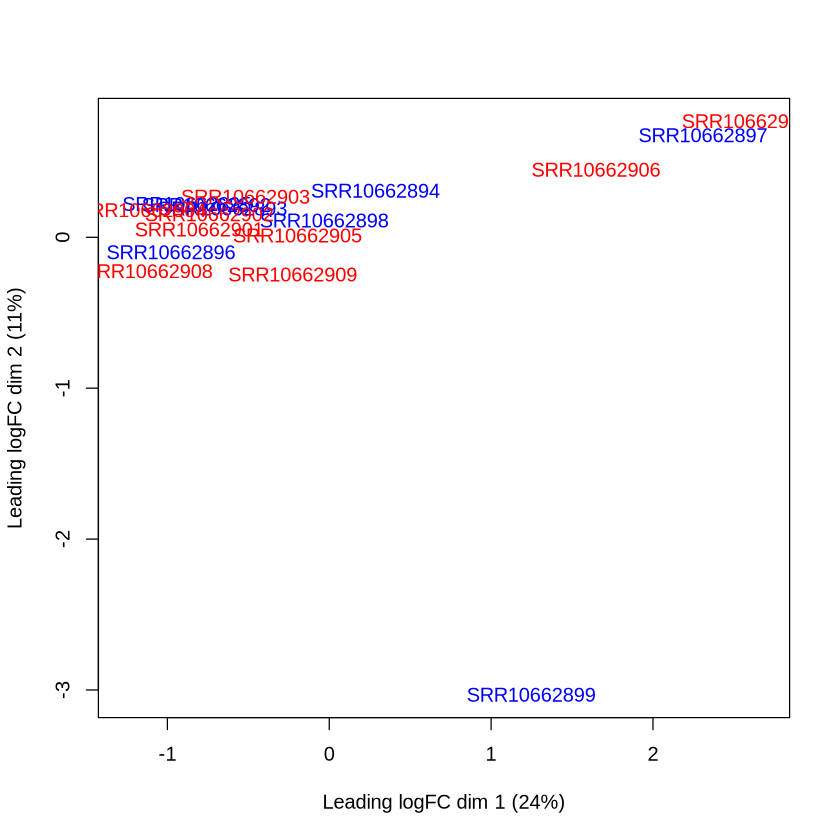

In [9]:
outliner = c("SRR10662900")
raw_counts_1 <- raw_counts[,-which(colnames(raw_counts) %in% outliner)]
sam2cond_1 <- sam2cond[-which(sam2cond[,"Run"] %in% outliner),]

y_1 <- DGEList(counts = raw_counts_1)
y_1 <- calcNormFactors(y_1)
plotMDS(y_1,col=c(rep("blue",8),rep("red",9)))

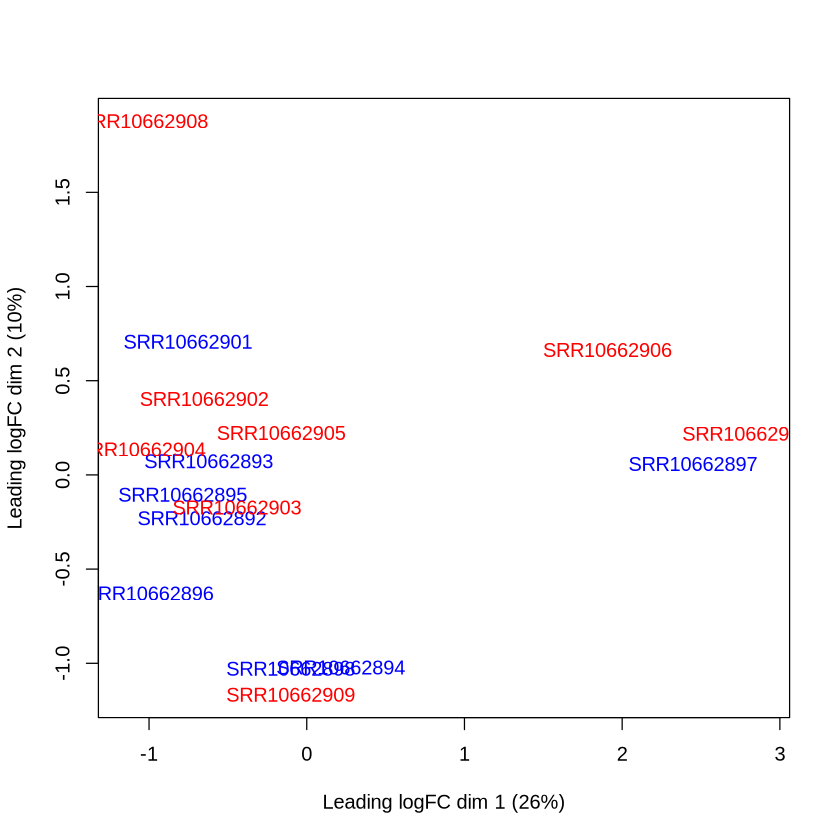

In [10]:
outliner = c("SRR10662900","SRR10662899")
raw_counts_1 <- raw_counts[,-which(colnames(raw_counts) %in% outliner)]
sam2cond_1 <- sam2cond[-which(sam2cond[,"Run"] %in% outliner),]

y_1 <- DGEList(counts = raw_counts_1)
y_1 <- calcNormFactors(y_1)
plotMDS(y_1,col=c(rep("blue",8),rep("red",9)))

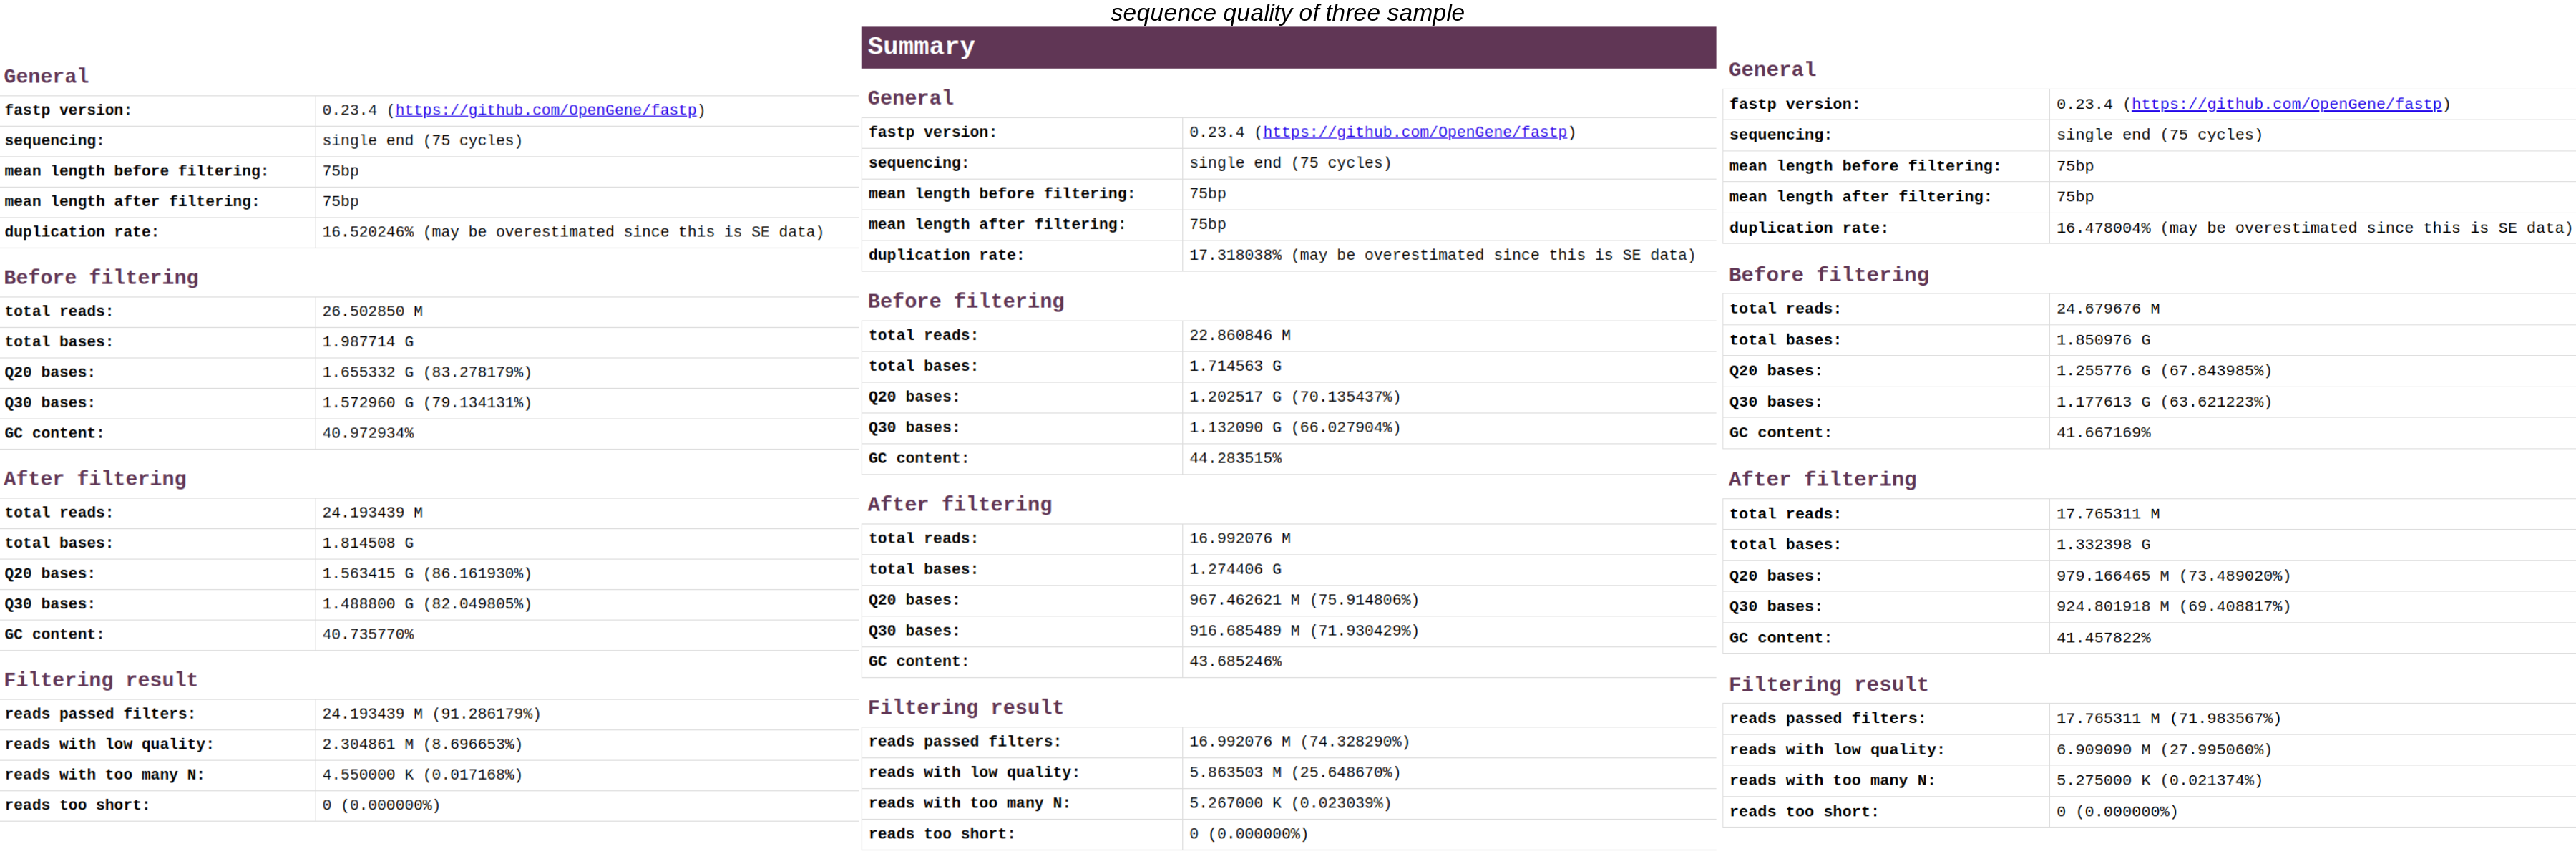

In [11]:
options(repr.plot.width = 30, repr.plot.height = 10)
img = readPNG("figs/SRR10662892.png")
p1 = rasterGrob(img, interpolate=TRUE)
img = readPNG("figs/SRR10662899.png")
p2 = rasterGrob(img, interpolate=TRUE)
img = readPNG("figs/SRR10662900.png")
p3 = rasterGrob(img, interpolate=TRUE)
grid.arrange(p1,p2,p3,nrow=1,ncol=3,
             top=textGrob("sequence quality of three sample",gp=gpar(fontsize=20,font=3)))

#### Summary: 
The PCA and Fastp quality control results indicate that the dataset has low sequencing quality, so the results should be interpreted with caution.

## Differiential analysis

In [12]:
# make sure the sample order are same in the matrix and the condition dataframe
all(colnames(raw_counts_1) == sam2cond_1$Run)

[1] TRUE

In [13]:
# create DESeq2 matrix
dds <- DESeqDataSetFromMatrix(countData = round(raw_counts_1), colData = sam2cond_1, design = ~condition)
dds

converting counts to integer mode



class: DESeqDataSet 
dim: 28277 16 
metadata(1): version
assays(1): counts
rownames(28277): A1BG A1BG-AS1 ... ZZEF1 ZZZ3
rowData names(0):
colnames(16): SRR10662892 SRR10662893 ... SRR10662908 SRR10662909
colData names(4): Sample.Name Run Bases condition

In [14]:
# relevel the condition to make the control is the reference
dds$condition <- relevel(dds$condition, ref="control")

In [15]:
# do the statistic analysis
dds <- DESeq(dds)
res <- results(dds)
res

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 34 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



log2 fold change (MLE): condition patient vs control 
Wald test p-value: condition patient vs control 
DataFrame with 28277 rows and 6 columns
          baseMean log2FoldChange     lfcSE      stat    pvalue      padj
         <numeric>      <numeric> <numeric> <numeric> <numeric> <numeric>
A1BG       6.12560      -0.444258  0.531791 -0.835400  0.403493        NA
A1BG-AS1   1.54026       0.192400  1.023686  0.187948  0.850917        NA
A1CF      30.02955      -0.495512  0.543722 -0.911333  0.362120  0.999484
A2M       10.23708      -0.342706  0.401200 -0.854204  0.392992  0.999484
A2M-AS1    8.47329      -0.521661  0.554460 -0.940846  0.346784        NA
...            ...            ...       ...       ...       ...       ...
ZYG11A     9.13436     -1.4043579  0.735310 -1.909885  0.056148  0.999484
ZYG11B    65.98718     -0.2237247  0.211783 -1.056384  0.290793  0.999484
ZYX       56.16032     -0.2175155  0.281915 -0.771563  0.440373  0.999484
ZZEF1     92.09321      0.1599408  0.155450

In [16]:
options(repr.matrix.max.cols=600, repr.matrix.max.rows=60)
res_fdr02 <- subset(res,padj<=0.2)
as.data.frame(res_fdr02)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CIRBP,98.56478,0.8769687,0.2335508,3.754938,1.733845e-04,0.15964382
PRRG3,410.12119,-1.7784155,0.3516706,-5.057049,4.257933e-07,0.00470459
RNA18SN1,115412.23387,-0.9087169,0.2118539,-4.289358,1.791907e-05,0.02260020
RNA18SN2,115483.82501,-0.9085312,0.2116642,-4.292324,1.768129e-05,0.02260020
RNA18SN3,115430.14489,-0.9075228,0.2118716,-4.283362,1.840907e-05,0.02260020
RNA18SN4,115404.62131,-0.9083235,0.2118606,-4.287364,1.808059e-05,0.02260020
RNA18SN5,115412.06845,-0.9079009,0.2117681,-4.287241,1.809061e-05,0.02260020
RNA45SN1,3815.78734,-0.7435285,0.1624457,-4.577090,4.714895e-06,0.01736496
RNA45SN4,3599.49168,-0.7802390,0.1847614,-4.222955,2.411204e-05,0.02664139


In [17]:
res_pv002 <- subset(res,pvalue<=0.02)
dim(as.data.frame(res_pv002))
write.table(file="DEGs_pv002.csv",as.data.frame(res_pv002),sep=",",quote=FALSE)

[1] 307   6

#### Summary: 
1. In the initial analysis, applying a false discovery rate (FDR) threshold of 0.2 resulted in only a few genes being identified as significantly differentially expressed. Moreover, there is no direct evidence linking the three genes—CIRBP, PRRG3, and SOGA3—to the peroxisome pathway. This limited detection may be attributed to the small sample size and potential issues with sequence data quality.​

2. To enhance the sensitivity of the analysis and identify more genes for downstream investigation, I adjusted the significance criteria to include genes with p-values ≤ 0.02. This approach aims to capture additional candidates that might be relevant to the study, acknowledging that a balance between stringency and discovery is necessary, especially when dealing with limited or noisy data.

## Check the performance of peroxisome pathway genes

In [19]:
pero_genes <- read.table("../data/peroxisomal_genes.tsv",header=T, stringsAsFactors=F)

In [20]:
res_pero <- res[pero_genes[,"genes"],]

In [21]:
options(repr.matrix.max.rows=600, repr.matrix.max.cols=60)
as.data.frame(res_pero)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ACOT8,7.808673,0.1494523379,0.4839194,0.308837281,0.75744531,NA
ECI2,19.004054,0.4962613344,0.2975102,1.668048192,0.09530616,0.9994840
SLC25A17,12.165903,-0.2200049709,0.3457952,-0.636229111,0.52462710,0.9994840
PMVK,8.637780,0.4344338711,0.3726335,1.165847681,0.24367604,NA
DHRS4,8.432680,-0.2134007989,0.3798996,-0.561729423,0.57430038,NA
SLC27A2,2.672644,0.3441046894,0.7238730,0.475366087,0.63452606,NA
PXMP4,18.455230,0.0004420626,0.4084668,0.001082249,0.99913649,0.9999952
CRAT,5.145257,0.3128884228,0.6122450,0.511050968,0.60931537,NA
DAO,1.925588,-0.3645873306,1.0448262,-0.348945430,0.72713028,NA


In [22]:
subset(res_pero,abs(log2FoldChange)>=1 | pvalue<=0.02) 

log2 fold change (MLE): condition patient vs control 
Wald test p-value: condition patient vs control 
DataFrame with 5 rows and 6 columns
        baseMean log2FoldChange     lfcSE      stat    pvalue      padj
       <numeric>      <numeric> <numeric> <numeric> <numeric> <numeric>
ABCD1    3.09376       1.237996  0.724240   1.70937 0.0873821        NA
DECR2    2.67883      -1.864862  1.021063  -1.82639 0.0677912        NA
NOS2     1.89398      -1.115455  1.092145  -1.02134 0.3070917        NA
NUDT12   7.84737      -1.244040  0.708630  -1.75556 0.0791643        NA
PPARA   23.64336      -0.922375  0.375806  -2.45439 0.0141124  0.999484

In [23]:
intersect(pero_genes[,"genes"], rownames(res_pv002))

[1] "PPARA"

#### Summary: 
1. PPARA appears to be a central regulator potentially involved in the development of MS.
2. To gain deeper insights, let's integrate the protein–protein interaction (PPI) data.

## Additional analysis (not included)
1. GO enrichment
2. Pathway enrichment